In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8")

# =========================
# CONFIG
# =========================
DATA_DIR = Path(".")   

TRAIN_FILE = "train.csv"             
ITEMS_FILE = "items.csv"
STORES_FILE = "stores.csv"
HOLIDAYS_FILE = "holidays_events.csv"
OIL_FILE = "oil.csv"
TRANSACTIONS_FILE = "transactions.csv"

TARGET_FAMILY = "BREAD/BAKERY"       # choose a perishable family you like
TARGET_STORE = 1                     # choose a store number
START_DATE = "2016-01-01"
END_DATE = "2017-08-15"

RL_PANEL_OUT = "rl_panel.parquet"
CHUNKSIZE = 5_000_000


In [2]:
# =========================
# 1. LOAD DIMENSION TABLES
# =========================

print("🔹 Loading items, stores, holidays, oil, transactions...")

items = pd.read_csv(DATA_DIR / ITEMS_FILE)
stores = pd.read_csv(DATA_DIR / STORES_FILE)
holidays = pd.read_csv(DATA_DIR / HOLIDAYS_FILE)
oil = pd.read_csv(DATA_DIR / OIL_FILE)
transactions = pd.read_csv(DATA_DIR / TRANSACTIONS_FILE)

print("items.shape:", items.shape)
print("stores.shape:", stores.shape)
print("holidays.shape:", holidays.shape)
print("oil.shape:", oil.shape)
print("transactions.shape:", transactions.shape)


🔹 Loading items, stores, holidays, oil, transactions...
items.shape: (4100, 4)
stores.shape: (54, 5)
holidays.shape: (350, 6)
oil.shape: (1218, 2)
transactions.shape: (83488, 3)


In [3]:
# =========================
# 1.1 EDA: ITEMS
# =========================
print("\n=== ITEMS: head() ===")
display(items.head())

print("\n=== ITEMS: family value_counts (top 15) ===")
print(items["family"].value_counts().head(15))

if "perishable" in items.columns:
    print("\n=== ITEMS: perishable value_counts ===")
    print(items["perishable"].value_counts())

    # Check which perishable families exist
    perishable_families = (
        items[items["perishable"] == 1]["family"]
        .value_counts()
        .head(15)
    )
    print("\n=== Top perishable families ===")
    print(perishable_families)



=== ITEMS: head() ===


,item_nbr,family,class,perishable
0,96995,GROCERY I,1093,0
1,99197,GROCERY I,1067,0
2,103501,CLEANING,3008,0
3,103520,GROCERY I,1028,0
4,103665,BREAD/BAKERY,2712,1



=== ITEMS: family value_counts (top 15) ===
family
GROCERY I              1334
BEVERAGES               613
CLEANING                446
PRODUCE                 306
DAIRY                   242
PERSONAL CARE           153
BREAD/BAKERY            134
HOME CARE               108
DELI                     91
MEATS                    84
HOME AND KITCHEN I       77
LIQUOR,WINE,BEER         73
FROZEN FOODS             55
POULTRY                  54
HOME AND KITCHEN II      45
Name: count, dtype: int64

=== ITEMS: perishable value_counts ===
perishable
0    3114
1     986
Name: count, dtype: int64

=== Top perishable families ===
family
PRODUCE           306
DAIRY             242
BREAD/BAKERY      134
DELI               91
MEATS              84
POULTRY            54
EGGS               41
PREPARED FOODS     26
SEAFOOD             8
Name: count, dtype: int64


In [4]:
# =========================
# 1.2 EDA: STORES
# =========================
print("\n=== STORES: head() ===")
display(stores.head())

print("\n=== STORES: cluster / type distribution (if present) ===")
for col in ["cluster", "type"]:
    if col in stores.columns:
        print(f"\n{col} value_counts:")
        print(stores[col].value_counts())



=== STORES: head() ===


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4



=== STORES: cluster / type distribution (if present) ===

cluster value_counts:
cluster
3     7
10    6
6     6
15    5
13    4
14    4
11    3
4     3
8     3
1     3
2     2
9     2
7     2
12    1
16    1
5     1
17    1
Name: count, dtype: int64

type value_counts:
type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64


In [5]:
# =========================
# 1.3 EDA: HOLIDAYS + OIL
# =========================

holidays["date"] = pd.to_datetime(holidays["date"])
oil["date"] = pd.to_datetime(oil["date"])

print("\n=== HOLIDAYS: head() ===")
display(holidays.head())

print("\nHoliday types:")
print(holidays["type"].value_counts())

print("\n=== OIL: head() ===")
display(oil.head())

print("\nOil price summary:")
display(oil["dcoilwtico"].describe())



=== HOLIDAYS: head() ===


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False



Holiday types:
type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

=== OIL: head() ===


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20



Oil price summary:


count    1175.000000
mean       67.714366
std        25.630476
min        26.190000
25%        46.405000
50%        53.190000
75%        95.660000
max       110.620000
Name: dcoilwtico, dtype: float64

In [6]:
# =========================
# 1.4 EDA: TRANSACTIONS
# =========================
transactions["date"] = pd.to_datetime(transactions["date"])

print("\n=== TRANSACTIONS: head() ===")
display(transactions.head())

print("\nTransactions for first few stores:")
display(
    transactions.groupby("store_nbr")["transactions"]
    .describe()
    .head(10)
)



=== TRANSACTIONS: head() ===


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922



Transactions for first few stores:


,count,mean,std,min,25%,50%,75%,max
store_nbr,,,,,,,,
1,1676.0,1523.844272,503.577771,10.0,1325.75,1746.0,1832.00,3023.0
2,1677.0,1920.036374,226.496662,6.0,1795.00,1889.0,2006.00,4060.0
3,1676.0,3201.879475,435.543650,2213.0,2888.75,3100.5,3457.00,6085.0
4,1676.0,1502.987470,228.510746,785.0,1355.00,1455.0,1613.00,3589.0
5,1677.0,1400.045915,225.305906,721.0,1263.00,1379.0,1496.00,3468.0
6,1676.0,1829.293556,299.100268,1380.0,1621.00,1729.0,2037.00,4256.0
7,1675.0,1788.652537,196.749730,1050.0,1684.50,1790.0,1892.00,3023.0
8,1676.0,2767.285800,311.196509,1360.0,2595.00,2740.5,2887.25,5261.0
9,1676.0,2097.948687,325.027157,1462.0,1867.00,2045.0,2271.00,4624.0


In [7]:
# =========================
# 2. STREAM train.csv & FILTER
# =========================

# Pick only perishable items in the target family
if "perishable" in items.columns:
    perishable_items = items[
        (items["family"] == TARGET_FAMILY) & (items["perishable"] == 1)
    ].copy()
else:
    # Fallback: use all items from that family
    perishable_items = items[items["family"] == TARGET_FAMILY].copy()

if perishable_items.empty:
    raise ValueError(
        f"No items found for family '{TARGET_FAMILY}'. "
        "Check the family name in items.csv."
    )

perishable_ids = set(perishable_items["item_nbr"].unique())
print(f"\n✅ Perishable items in family '{TARGET_FAMILY}': {len(perishable_ids)}")

usecols = ["date", "store_nbr", "item_nbr", "unit_sales", "onpromotion"]
train_path = DATA_DIR / TRAIN_FILE

filtered_chunks = []
total_rows_scanned = 0
total_rows_kept = 0

print("\n🔹 Reading train.csv in chunks...")
for chunk in pd.read_csv(
    train_path,
    usecols=usecols,
    parse_dates=["date"],
    chunksize=CHUNKSIZE,
):
    total_rows_scanned += len(chunk)

    mask = (
        (chunk["store_nbr"] == TARGET_STORE) &
        (chunk["item_nbr"].isin(perishable_ids)) &
        (chunk["date"] >= START_DATE) &
        (chunk["date"] <= END_DATE)
    )
    filtered = chunk.loc[mask].copy()
    kept = len(filtered)
    total_rows_kept += kept

    if kept > 0:
        filtered_chunks.append(filtered)

    print(
        f"  Scanned: {total_rows_scanned:,} rows, "
        f"Kept this chunk: {kept:,} (Total kept: {total_rows_kept:,})",
        end="\r"
    )

print("\n\n✅ Finished streaming train.csv.")
if not filtered_chunks:
    raise ValueError(
        "No matching rows found in train.csv for this store/family/date range. "
        "Try changing TARGET_STORE, TARGET_FAMILY or date range."
    )

sales = pd.concat(filtered_chunks, ignore_index=True)
print("Filtered sales shape:", sales.shape)
display(sales.head())



✅ Perishable items in family 'BREAD/BAKERY': 134

🔹 Reading train.csv in chunks...
  Scanned: 20,000,000 rows, Kept this chunk: 0 (Total kept: 0)

C:\Users\suman\AppData\Local\Temp\ipykernel_41648\937493133.py:31: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(


  Scanned: 125,497,040 rows, Kept this chunk: 264 (Total kept: 41,973)9)

✅ Finished streaming train.csv.
Filtered sales shape: (41973, 5)


,date,store_nbr,item_nbr,unit_sales,onpromotion
0,2016-01-02,1,153398,2.0,False
1,2016-01-02,1,165718,1.0,False
2,2016-01-02,1,265279,2.0,False
3,2016-01-02,1,310644,8.0,False
4,2016-01-02,1,310647,2.0,False



=== SALES: basic info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41973 entries, 0 to 41972
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         41973 non-null  datetime64[ns]
 1   store_nbr    41973 non-null  int64         
 2   item_nbr     41973 non-null  int64         
 3   unit_sales   41973 non-null  float64       
 4   onpromotion  41973 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 1.3 MB
None

=== SALES: describe numeric ===


,unit_sales
count,41973.000000
mean,5.336711
std,6.489051
min,-2.000000
25%,2.000000
50%,3.000000
75%,6.000000
max,94.000000



Onpromotion value_counts:
onpromotion
False    39491
True      2482
Name: count, dtype: int64


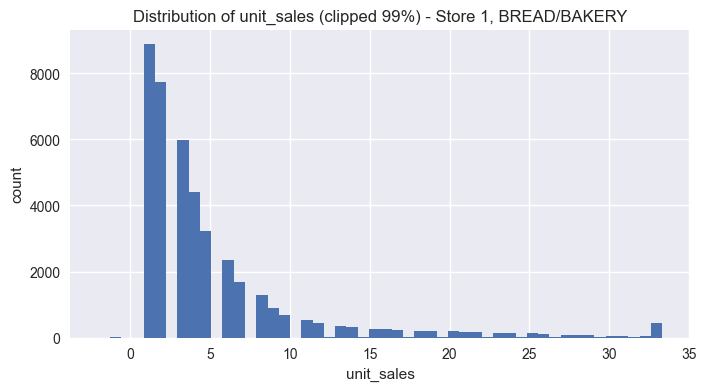

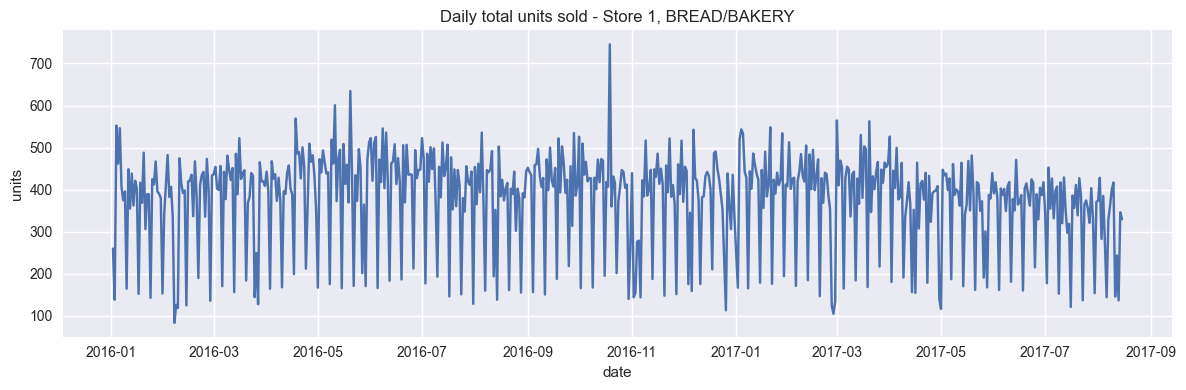


Average unit_sales per record (promo vs non-promo):
onpromotion
No Promo    5.274538
Promo       6.325947
Name: unit_sales, dtype: float64


In [8]:
# =========================
# 2.1 EDA: FILTERED SALES
# =========================

print("\n=== SALES: basic info ===")
print(sales.info())

print("\n=== SALES: describe numeric ===")
display(sales[["unit_sales"]].describe())

print("\nOnpromotion value_counts:")
print(sales["onpromotion"].value_counts(dropna=False))

# Convert onpromotion to 0/1 for later
sales["onpromotion"] = sales["onpromotion"].fillna(False).astype(int)

# Distribution of unit_sales
plt.figure(figsize=(8, 4))
sales["unit_sales"].clip(upper=sales["unit_sales"].quantile(0.99)).hist(bins=50)
plt.title(f"Distribution of unit_sales (clipped 99%) - Store {TARGET_STORE}, {TARGET_FAMILY}")
plt.xlabel("unit_sales")
plt.ylabel("count")
plt.show()

# Time series of total daily sales (raw)
daily_raw = (
    sales.groupby("date")["unit_sales"]
    .sum()
    .reset_index(name="total_units")
    .sort_values("date")
)

plt.figure(figsize=(12, 4))
plt.plot(daily_raw["date"], daily_raw["total_units"])
plt.title(f"Daily total units sold - Store {TARGET_STORE}, {TARGET_FAMILY}")
plt.xlabel("date")
plt.ylabel("units")
plt.tight_layout()
plt.show()

# Promo vs non-promo average sales per record
avg_promo = (
    sales.groupby("onpromotion")["unit_sales"]
    .mean()
    .rename({0: "No Promo", 1: "Promo"})
)
print("\nAverage unit_sales per record (promo vs non-promo):")
print(avg_promo)


In [9]:
# =========================
# 3. BUILD DAILY PANEL FOR RL
# =========================

# Aggregate to one row per date for this store+family
daily = (
    sales.groupby("date")
    .agg(
        base_demand=("unit_sales", "sum"),      # total units sold that day
        promo_frac=("onpromotion", "mean"),     # fraction of items on promo
        num_records=("item_nbr", "count"),      # how many SKU-day records
    )
    .reset_index()
    .sort_values("date")
)

print("\n=== DAILY aggregated (before merges) ===")
display(daily.head())
display(daily.describe())



=== DAILY aggregated (before merges) ===


,date,base_demand,promo_frac,num_records
0,2016-01-02,259.811,0.016393,61
1,2016-01-03,138.275,0.025000,40
2,2016-01-04,552.172,0.000000,74
3,2016-01-05,461.738,0.000000,72
4,2016-01-06,546.093,0.000000,72


,date,base_demand,promo_frac,num_records
count,590,590.000000,590.000000,590.000000
mean,2016-10-23 06:37:49.830508544,379.657264,0.058492,71.140678
min,2016-01-02 00:00:00,83.352000,0.000000,33.000000
25%,2016-05-28 06:00:00,354.057000,0.013158,69.000000
50%,2016-10-22 12:00:00,410.350500,0.039088,74.000000
75%,2017-03-20 18:00:00,447.116750,0.090909,78.000000
max,2017-08-15 00:00:00,745.513000,0.311688,89.000000
std,NaN,111.371375,0.060081,9.932995


In [10]:
# --- Merge transactions (footfall) for this store --- #
trans_store = transactions[transactions["store_nbr"] == TARGET_STORE].copy()
trans_store = trans_store.rename(columns={"transactions": "footfall"})

daily = daily.merge(
    trans_store[["date", "footfall"]],
    on="date",
    how="left"
)

print("\nAfter merging transactions:")
display(daily.head())



After merging transactions:


,date,base_demand,promo_frac,num_records,footfall
0,2016-01-02,259.811,0.016393,61,NaN
1,2016-01-03,138.275,0.025000,40,NaN
2,2016-01-04,552.172,0.000000,74,10.0
3,2016-01-05,461.738,0.000000,72,1840.0
4,2016-01-06,546.093,0.000000,72,1996.0


In [11]:
# --- Merge oil prices --- #
daily = daily.merge(
    oil[["date", "dcoilwtico"]],
    on="date",
    how="left"
)

print("\nAfter merging oil prices:")
display(daily.head())



After merging oil prices:


,date,base_demand,promo_frac,num_records,footfall,dcoilwtico
0,2016-01-02,259.811,0.016393,61,NaN,NaN
1,2016-01-03,138.275,0.025000,40,NaN,NaN
2,2016-01-04,552.172,0.000000,74,10.0,36.81
3,2016-01-05,461.738,0.000000,72,1840.0,35.97
4,2016-01-06,546.093,0.000000,72,1996.0,33.97


In [12]:
# --- Build daily holiday flag --- #
holidays_non_trans = holidays[~holidays["transferred"]].copy()

hol_daily = (
    holidays_non_trans
    .groupby("date")
    .agg(is_holiday=("type", lambda x: 1))
    .reset_index()
)

daily = daily.merge(hol_daily, on="date", how="left")
daily["is_holiday"] = daily["is_holiday"].fillna(0).astype(int)

print("\nAfter merging holidays:")
display(daily.head())



After merging holidays:


,date,base_demand,promo_frac,num_records,footfall,dcoilwtico,is_holiday
0,2016-01-02,259.811,0.016393,61,NaN,NaN,0
1,2016-01-03,138.275,0.025000,40,NaN,NaN,0
2,2016-01-04,552.172,0.000000,74,10.0,36.81,0
3,2016-01-05,461.738,0.000000,72,1840.0,35.97,0
4,2016-01-06,546.093,0.000000,72,1996.0,33.97,0


In [13]:
# --- Add calendar features --- #
daily["dow"] = daily["date"].dt.dayofweek   # 0=Mon
daily["weekofyear"] = daily["date"].dt.isocalendar().week.astype(int)
daily["month"] = daily["date"].dt.month
daily["year"] = daily["date"].dt.year

# Basic numeric imputation
numeric_cols = ["base_demand", "promo_frac", "footfall", "dcoilwtico"]
for col in numeric_cols:
    if col in daily.columns:
        median_val = daily[col].median()
        daily[col] = daily[col].fillna(median_val)

# Time-series aware fixing for footfall
if "footfall" in daily.columns:
    daily["footfall"] = (
        daily["footfall"]
        .fillna(method="ffill")
        .fillna(method="bfill")
        .fillna(daily["footfall"].median())
    )

# Time-series aware fixing for oil price
if "dcoilwtico" in daily.columns:
    daily["dcoilwtico"] = (
        daily["dcoilwtico"]
        .fillna(method="ffill")
        .fillna(method="bfill")
        .fillna(daily["dcoilwtico"].median())
    )

# Clip negatives
if "base_demand" in daily.columns:
    daily["base_demand"] = daily["base_demand"].clip(lower=0.0)

    # Optional: clip extreme spikes at 99th percentile
    q99 = daily["base_demand"].quantile(0.99)
    daily["base_demand"] = daily["base_demand"].clip(upper=q99)

# Final sort & reset index
daily = daily.sort_values("date").reset_index(drop=True)

print("\n=== FINAL DAILY PANEL (RL input) ===")
display(daily.head())
display(daily.describe())



=== FINAL DAILY PANEL (RL input) ===


C:\Users\suman\AppData\Local\Temp\ipykernel_41648\342777300.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")
C:\Users\suman\AppData\Local\Temp\ipykernel_41648\342777300.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="bfill")
C:\Users\suman\AppData\Local\Temp\ipykernel_41648\342777300.py:27: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")
C:\Users\suman\AppData\Local\Temp\ipykernel_41648\342777300.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="bfill")


,date,base_demand,promo_frac,num_records,footfall,dcoilwtico,is_holiday,dow,weekofyear,month,year
0,2016-01-02,259.811,0.016393,61,1725.5,47.00,0,5,53,1,2016
1,2016-01-03,138.275,0.025000,40,1725.5,47.00,0,6,53,1,2016
2,2016-01-04,552.172,0.000000,74,10.0,36.81,0,0,1,1,2016
3,2016-01-05,461.738,0.000000,72,1840.0,35.97,0,1,1,1,2016
4,2016-01-06,546.093,0.000000,72,1996.0,33.97,0,2,1,1,2016


,date,base_demand,promo_frac,num_records,footfall,dcoilwtico,is_holiday,dow,weekofyear,month,year
count,590,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000,590.000000
mean,2016-10-23 06:37:49.830508544,379.051834,0.058492,71.140678,1504.584746,46.044017,0.155932,2.989831,22.730508,5.664407,2016.383051
min,2016-01-02 00:00:00,83.352000,0.000000,33.000000,10.000000,26.190000,0.000000,0.000000,1.000000,1.000000,2016.000000
25%,2016-05-28 06:00:00,354.057000,0.013158,69.000000,1329.500000,45.322500,0.000000,1.000000,11.000000,3.000000,2016.000000
50%,2016-10-22 12:00:00,410.350500,0.039088,74.000000,1725.500000,47.000000,0.000000,3.000000,22.000000,5.000000,2016.000000
75%,2017-03-20 18:00:00,447.116750,0.090909,78.000000,1807.000000,48.712500,0.000000,5.000000,32.000000,8.000000,2017.000000
max,2017-08-15 00:00:00,553.314350,0.311688,89.000000,3023.000000,54.480000,1.000000,6.000000,53.000000,12.000000,2017.000000
std,NaN,110.063909,0.060081,9.932995,491.161651,5.322181,0.363099,2.001671,13.993823,3.204293,0.486543


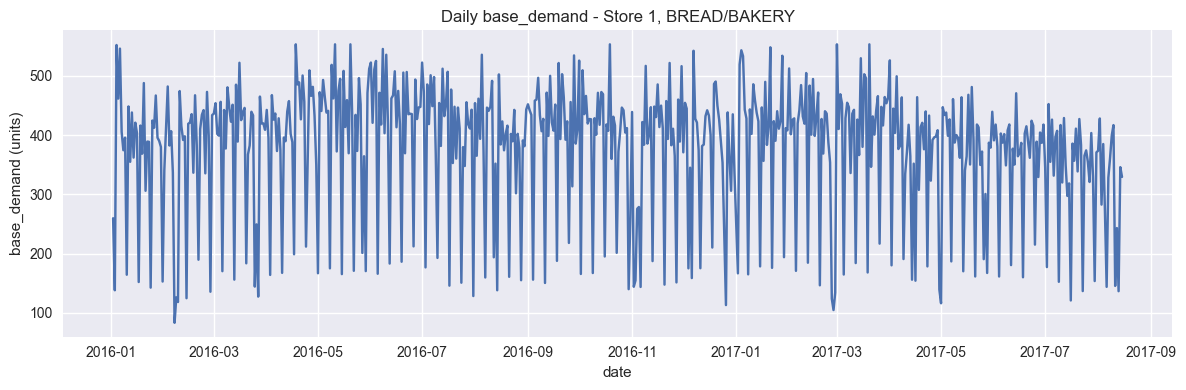

In [14]:
# =========================
# 4. EDA ON RL PANEL
# =========================

# Time series of base_demand
plt.figure(figsize=(12, 4))
plt.plot(daily["date"], daily["base_demand"])
plt.title(f"Daily base_demand - Store {TARGET_STORE}, {TARGET_FAMILY}")
plt.xlabel("date")
plt.ylabel("base_demand (units)")
plt.tight_layout()
plt.show()

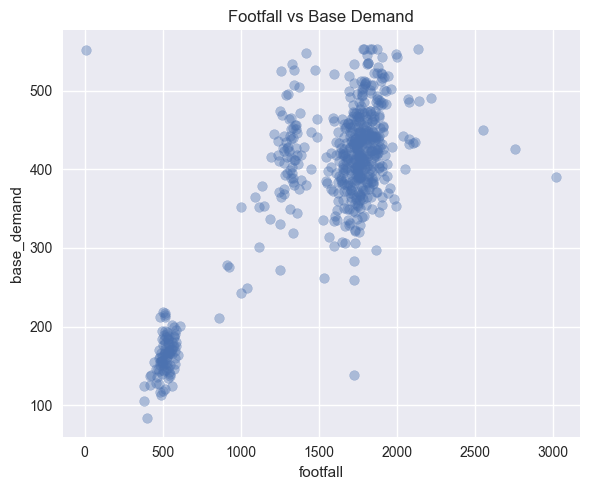

In [15]:
# Relationship: footfall vs base_demand
plt.figure(figsize=(6, 5))
plt.scatter(
    daily["footfall"],
    daily["base_demand"],
    alpha=0.4
)
plt.title("Footfall vs Base Demand")
plt.xlabel("footfall")
plt.ylabel("base_demand")
plt.tight_layout()
plt.show()

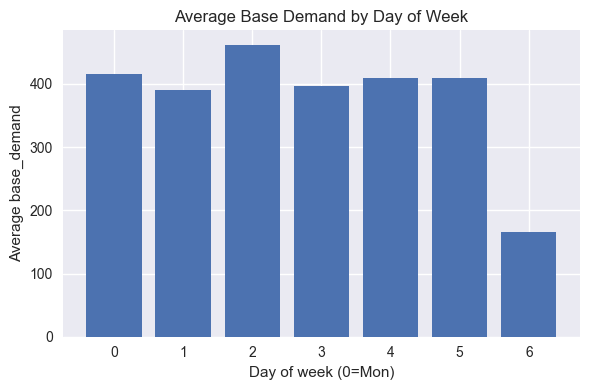

In [16]:
# === EDA: Day-of-week seasonality ===
dow_stats = (
    daily.groupby("dow")["base_demand"]
    .mean()
    .reset_index()
    .sort_values("dow")
)

plt.figure(figsize=(6, 4))
plt.bar(dow_stats["dow"], dow_stats["base_demand"])
plt.title("Average Base Demand by Day of Week")
plt.xlabel("Day of week (0=Mon)")
plt.ylabel("Average base_demand")
plt.tight_layout()
plt.show()


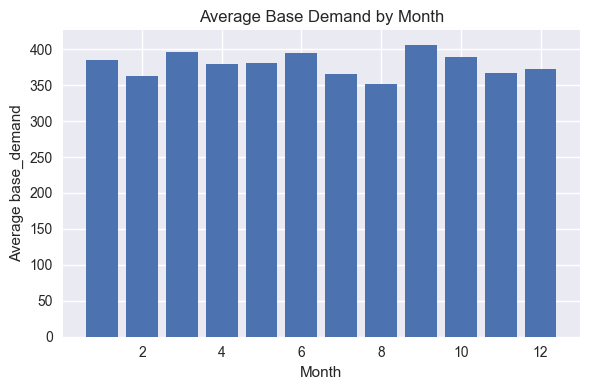

In [17]:
# === EDA: Month-of-year seasonality ===
month_stats = (
    daily.groupby("month")["base_demand"]
    .mean()
    .reset_index()
    .sort_values("month")
)

plt.figure(figsize=(6, 4))
plt.bar(month_stats["month"], month_stats["base_demand"])
plt.title("Average Base Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average base_demand")
plt.tight_layout()
plt.show()


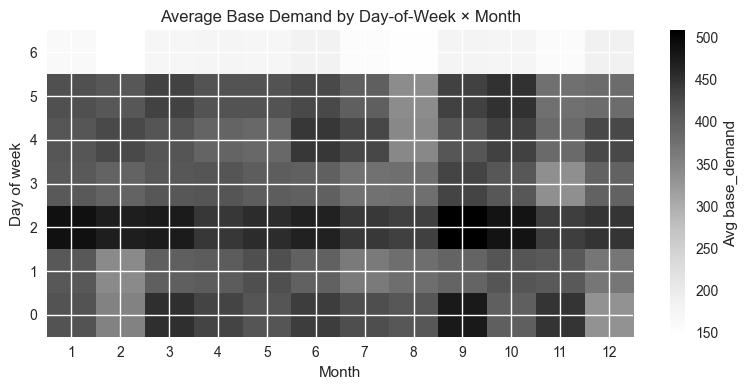

In [18]:
# === EDA: DOW x Month heatmap ===
pivot = daily.pivot_table(
    index="dow",
    columns="month",
    values="base_demand",
    aggfunc="mean"
)

plt.figure(figsize=(8, 4))
im = plt.imshow(pivot, aspect="auto", origin="lower")
plt.colorbar(im, label="Avg base_demand")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Average Base Demand by Day-of-Week × Month")
plt.xlabel("Month")
plt.ylabel("Day of week")
plt.tight_layout()
plt.show()


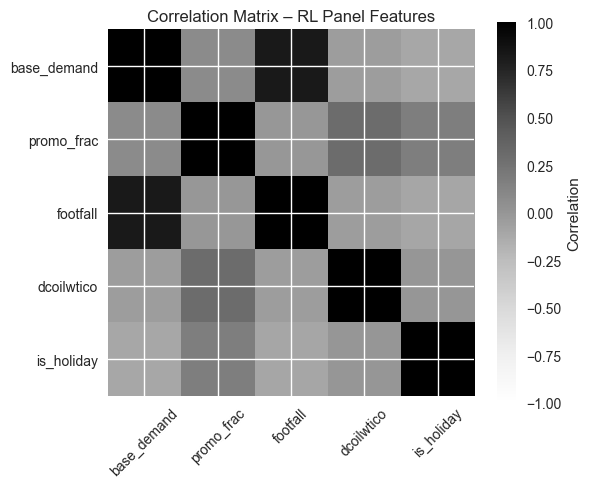

In [19]:
# === EDA: Correlation matrix ===
corr_cols = ["base_demand", "promo_frac", "footfall", "dcoilwtico", "is_holiday"]
existing_corr_cols = [c for c in corr_cols if c in daily.columns]

corr = daily[existing_corr_cols].corr()

plt.figure(figsize=(6, 5))
im = plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(existing_corr_cols)), existing_corr_cols, rotation=45)
plt.yticks(range(len(existing_corr_cols)), existing_corr_cols)
plt.title("Correlation Matrix – RL Panel Features")
plt.tight_layout()
plt.show()


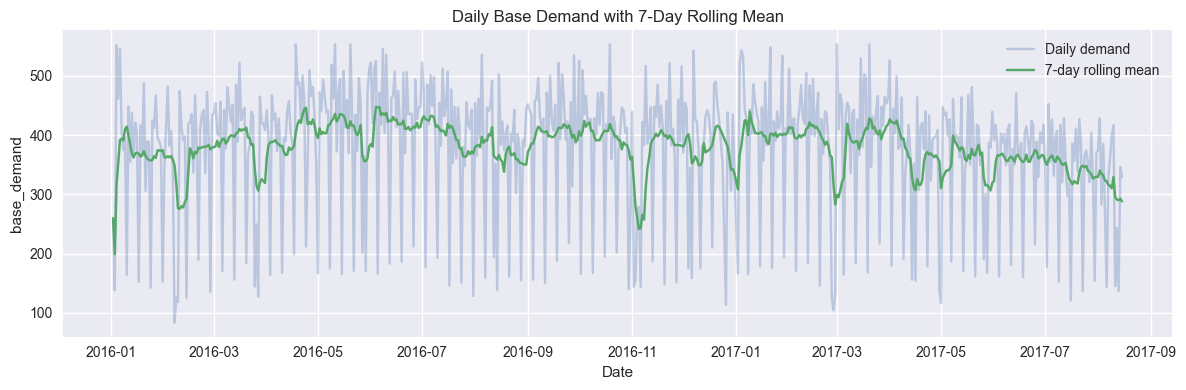

In [20]:
# === EDA: Rolling demand ===
daily = daily.sort_values("date").reset_index(drop=True)

daily["bd_7d_mean"] = daily["base_demand"].rolling(7, min_periods=1).mean()
daily["bd_7d_std"]  = daily["base_demand"].rolling(7, min_periods=1).std()

plt.figure(figsize=(12, 4))
plt.plot(daily["date"], daily["base_demand"], alpha=0.3, label="Daily demand")
plt.plot(daily["date"], daily["bd_7d_mean"], label="7-day rolling mean")
plt.title("Daily Base Demand with 7-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("base_demand")
plt.legend()
plt.tight_layout()
plt.show()


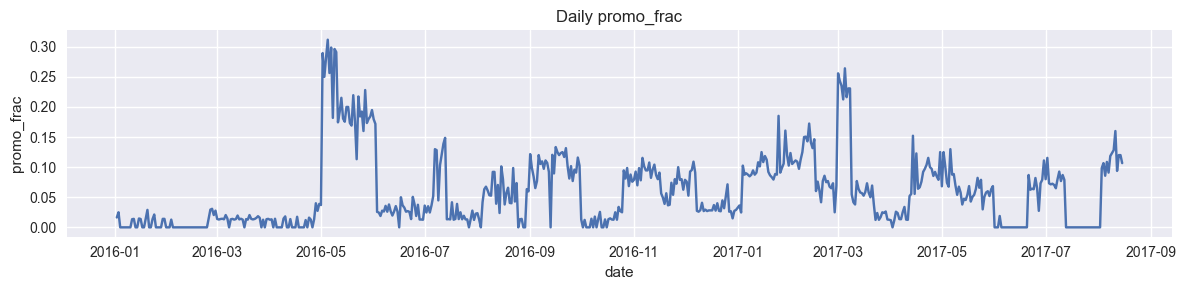

In [21]:
# Promo fraction over time
plt.figure(figsize=(12, 3))
plt.plot(daily["date"], daily["promo_frac"])
plt.title("Daily promo_frac")
plt.xlabel("date")
plt.ylabel("promo_frac")
plt.tight_layout()
plt.show()

In [22]:
# Holiday vs non-holiday average demand
holiday_stats = (
    daily.groupby("is_holiday")["base_demand"]
    .mean()
    .rename({0: "Non-holiday", 1: "Holiday"})
)
print("\nAverage base_demand (holiday vs non-holiday):")
print(holiday_stats)


Average base_demand (holiday vs non-holiday):
is_holiday
Non-holiday    384.408061
Holiday        350.058345
Name: base_demand, dtype: float64


In [23]:
# =========================
# 5. SAVE RL PANEL
# =========================

print("\nSaving RL panel to:", RL_PANEL_OUT)
daily.to_parquet(RL_PANEL_OUT, index=False)
print("✅ Saved:", RL_PANEL_OUT)


Saving RL panel to: rl_panel.parquet
✅ Saved: rl_panel.parquet
